<a href="https://colab.research.google.com/github/Rohit-U76/RL/blob/main/RL_Assignment_No_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bandit 0: True Mean = 1.62, Estimated Mean = 1.66, Pulls = 247
Bandit 1: True Mean = -0.61, Estimated Mean = -0.59, Pulls = 98
Bandit 2: True Mean = -0.53, Estimated Mean = -0.61, Pulls = 104
Bandit 3: True Mean = -1.07, Estimated Mean = -1.06, Pulls = 102
Bandit 4: True Mean = 0.87, Estimated Mean = 0.78, Pulls = 93
Bandit 5: True Mean = -2.30, Estimated Mean = -2.36, Pulls = 114
Bandit 6: True Mean = 1.74, Estimated Mean = 1.75, Pulls = 8928
Bandit 7: True Mean = -0.76, Estimated Mean = -0.90, Pulls = 98
Bandit 8: True Mean = 0.32, Estimated Mean = 0.18, Pulls = 113
Bandit 9: True Mean = -0.25, Estimated Mean = -0.40, Pulls = 103


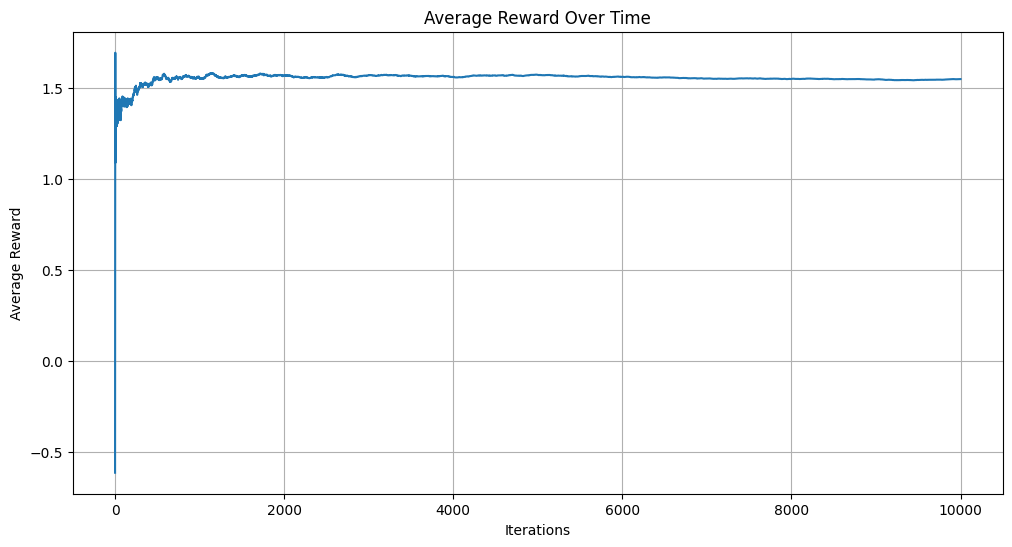

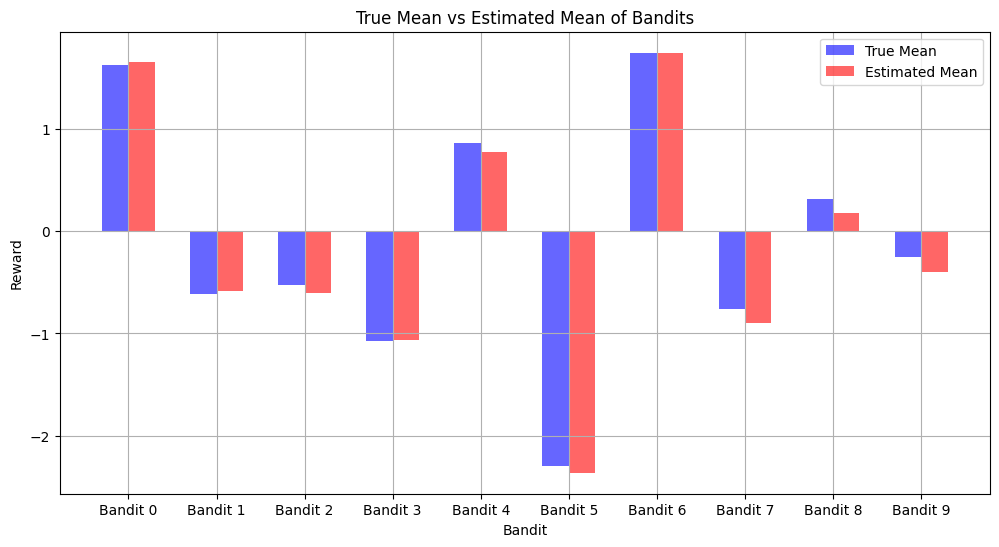

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Bandit Class
# ------------------------------
class Bandit:
    def __init__(self, true_mean):
        self.true_mean = true_mean        # true expected reward
        self.estimated_mean = 0           # running average of observed rewards
        self.num_pulls = 0                # number of times this bandit was pulled

    def pull(self):
        """Simulate pulling the bandit's arm"""
        return np.random.randn() + self.true_mean

    def update(self, reward):
        """Update running average using incremental formula"""
        self.num_pulls += 1
        self.estimated_mean += (reward - self.estimated_mean) / self.num_pulls

# ------------------------------
# Epsilon-Greedy Action Selection
# ------------------------------
def epsilon_greedy(bandits, epsilon, iterations):
    rewards = np.zeros(iterations)
    for i in range(iterations):
        if np.random.random() < epsilon:
            # Explore: choose a random bandit
            j = np.random.randint(len(bandits))
        else:
            # Exploit: choose the bandit with the highest estimated mean
            j = np.argmax([b.estimated_mean for b in bandits])

        reward = bandits[j].pull()
        bandits[j].update(reward)
        rewards[i] = reward
    return rewards

# ------------------------------
# Main Simulation
# ------------------------------
def main():
    np.random.seed(1)  # reproducibility

    # Create 10 bandits with random true means
    true_means = np.random.randn(10)
    bandits = [Bandit(mu) for mu in true_means]

    # ε-greedy parameters
    epsilon = 0.1       # 10% exploration
    iterations = 10000  # total steps

    # Run simulation
    rewards = epsilon_greedy(bandits, epsilon, iterations)

    # Display results
    for i, b in enumerate(bandits):
        print(f"Bandit {i}: True Mean = {b.true_mean:.2f}, "
              f"Estimated Mean = {b.estimated_mean:.2f}, Pulls = {b.num_pulls}")

    # Cumulative and average rewards
    cumulative_rewards = np.cumsum(rewards)
    average_rewards = cumulative_rewards / (np.arange(iterations) + 1)

    # Plot average reward over time
    plt.figure(figsize=(12, 6))
    plt.plot(average_rewards)
    plt.xlabel('Iterations')
    plt.ylabel('Average Reward')
    plt.title('Average Reward Over Time')
    plt.grid(True)
    plt.show()

    # Plot true mean vs estimated mean
    estimated_means = [b.estimated_mean for b in bandits]
    index = np.arange(len(bandits))
    bar_width = 0.3

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(index, true_means, bar_width, label='True Mean', alpha=0.6, color='blue')
    ax.bar(index + bar_width, estimated_means, bar_width, label='Estimated Mean', alpha=0.6, color='red')
    ax.set_xlabel('Bandit')
    ax.set_ylabel('Reward')
    ax.set_title('True Mean vs Estimated Mean of Bandits')
    ax.set_xticks(index + bar_width / 2)
    ax.set_xticklabels([f'Bandit {i}' for i in range(len(bandits))])
    ax.legend()
    ax.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

Practical Assignment 5
K-Armed Bandit Problem
1. Introduction

The K-Armed Bandit problem is a fundamental problem in reinforcement learning.
It involves an agent choosing from K possible actions (bandits), each giving a stochastic reward.

The agent’s goal is to maximize cumulative reward by learning the best actions over repeated trials.

In this assignment, we implement a 10-Armed Bandit using:

Incremental sample averaging to estimate action values

ε-greedy action selection to balance exploration and exploitation

2. Objective

Implement a 10-Armed Bandit simulation

Use incremental sample averaging to estimate rewards

Use ε-greedy policy for action selection

Train the agent for 10,000 iterations in steps of 50

Visualize average rewards over time and true vs estimated means

3. Problem Description

Number of bandits (K): 10

Each bandit has a true mean reward sampled from a normal distribution

Rewards are stochastic, drawn from a normal distribution centered at each bandit’s true mean

The agent chooses actions using ε-greedy policy:

Strategy	Description
Exploit	Choose the bandit with the highest estimated mean
Explore	Choose a random bandit with probability ε = 0.1

Goal: Maximize cumulative reward while learning the best bandit

4. Reinforcement Learning Components

Agent: The learner selecting bandit arms

Environment: The 10-Armed Bandit problem providing stochastic rewards

Action: Pulling one of the 10 bandit arms

Reward: Sampled from a normal distribution centered on the bandit’s true mean

5. Python Implementation
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Bandit Class
# ------------------------------
class Bandit:
    def __init__(self, true_mean):
        self.true_mean = true_mean        # true expected reward
        self.estimated_mean = 0           # running average of observed rewards
        self.num_pulls = 0                # number of times this bandit was pulled

    def pull(self):
        """Simulate pulling the bandit's arm"""
        return np.random.randn() + self.true_mean

    def update(self, reward):
        """Update running average using incremental formula"""
        self.num_pulls += 1
        self.estimated_mean += (reward - self.estimated_mean) / self.num_pulls

# ------------------------------
# Epsilon-Greedy Action Selection
# ------------------------------
def epsilon_greedy(bandits, epsilon, iterations):
    rewards = np.zeros(iterations)
    for i in range(iterations):
        if np.random.random() < epsilon:
            # Explore: choose a random bandit
            j = np.random.randint(len(bandits))
        else:
            # Exploit: choose the bandit with the highest estimated mean
            j = np.argmax([b.estimated_mean for b in bandits])
        
        reward = bandits[j].pull()
        bandits[j].update(reward)
        rewards[i] = reward
    return rewards

# ------------------------------
# Main Simulation
# ------------------------------
def main():
    np.random.seed(1)  # reproducibility
    
    # Create 10 bandits with random true means
    true_means = np.random.randn(10)
    bandits = [Bandit(mu) for mu in true_means]

    # ε-greedy parameters
    epsilon = 0.1       # 10% exploration
    iterations = 10000  # total steps

    # Run simulation
    rewards = epsilon_greedy(bandits, epsilon, iterations)

    # Display results
    for i, b in enumerate(bandits):
        print(f"Bandit {i}: True Mean = {b.true_mean:.2f}, "
              f"Estimated Mean = {b.estimated_mean:.2f}, Pulls = {b.num_pulls}")

    # Cumulative and average rewards
    cumulative_rewards = np.cumsum(rewards)
    average_rewards = cumulative_rewards / (np.arange(iterations) + 1)

    # Plot average reward over time
    plt.figure(figsize=(12, 6))
    plt.plot(average_rewards)
    plt.xlabel('Iterations')
    plt.ylabel('Average Reward')
    plt.title('Average Reward Over Time')
    plt.grid(True)
    plt.show()

    # Plot true mean vs estimated mean
    estimated_means = [b.estimated_mean for b in bandits]
    index = np.arange(len(bandits))
    bar_width = 0.3

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(index, true_means, bar_width, label='True Mean', alpha=0.6, color='blue')
    ax.bar(index + bar_width, estimated_means, bar_width, label='Estimated Mean', alpha=0.6, color='red')
    ax.set_xlabel('Bandit')
    ax.set_ylabel('Reward')
    ax.set_title('True Mean vs Estimated Mean of Bandits')
    ax.set_xticks(index + bar_width / 2)
    ax.set_xticklabels([f'Bandit {i}' for i in range(len(bandits))])
    ax.legend()
    ax.grid(True)
    plt.show()

if __name__ == "__main__":
    main()
6. Observations

The agent learns to favor the bandit with the highest true mean over time

Average reward gradually converges to the optimal reward

Estimated means approximate the true means as more pulls occur

Exploration (ε = 0.1) ensures the agent does not get stuck on suboptimal bandits

7. Advantages

Demonstrates exploration-exploitation tradeoff

Uses incremental averaging to estimate bandit values efficiently

Simple and extendable to more complex reinforcement learning algorithms

8. Limitations

Only works for stationary bandits (true mean does not change)

Does not consider context or state (stateless problem)

Performance depends on choice of ε

9. Conclusion

This practical assignment demonstrates the core concepts of reinforcement learning using the 10-Armed Bandit problem. The simulation shows how an agent can learn optimal actions through repeated interactions with the environment using the ε-greedy policy and incremental sample averaging.

Key takeaways:

The agent successfully identifies the bandit with the highest expected reward over time.

Exploration ensures all bandits are occasionally tested, preventing premature convergence to suboptimal choices.

Estimated means converge to true means, illustrating effective learning through repeated trials.

The exercise reinforces the concepts of exploration-exploitation tradeoff, reward estimation, and incremental learning, which are fundamental to reinforcement learning.

Overall, the experiment provides a solid foundation for understanding how agents can learn optimal behavior in stochastic environments.